In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)


OpenCV version: 4.12.0


In [2]:
def show(title, img):
    plt.figure(figsize=(5,5))
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


In [3]:
def hsv_segment(image_path, lower_hsv, upper_hsv):
    img = cv2.imread(image_path)
    
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask based on colour thresholds
    mask = cv2.inRange(hsv, lower_hsv, upper_hsv)

    # Clean noise (morphology)
    kernel = np.ones((5,5), np.uint8)
    mask_clean = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, kernel)

    # Extract foreground
    fg = cv2.bitwise_and(img, img, mask=mask_clean)

    return img, mask_clean, fg


In [4]:
lower_hsv = np.array([20, 40, 40])   
upper_hsv = np.array([85, 255, 255])


In [5]:
def grabcut_segment(image_path):
    img = cv2.imread(image_path)
    
    mask = np.zeros(img.shape[:2], np.uint8)

    bgModel = np.zeros((1,65), np.float64)
    fgModel = np.zeros((1,65), np.float64)

    # Rectangle around the object
    h, w = img.shape[:2]
    rect = (20, 20, w-40, h-40)

    cv2.grabCut(img, mask, rect, bgModel, fgModel, 5, cv2.GC_INIT_WITH_RECT)

    final_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

    fg = img * final_mask[:, :, np.newaxis]

    return img, final_mask * 255, fg


In [6]:
image_path = "images/img1.jpg"   


Processing: images/img1.jpg


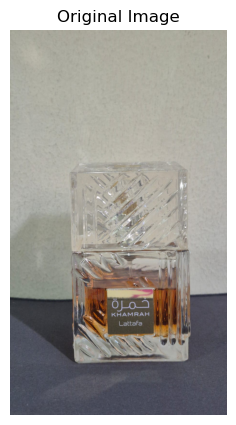

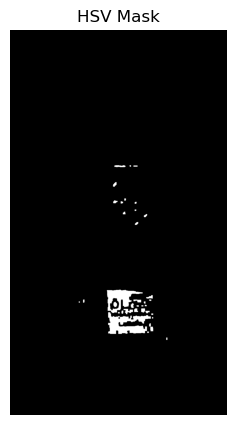

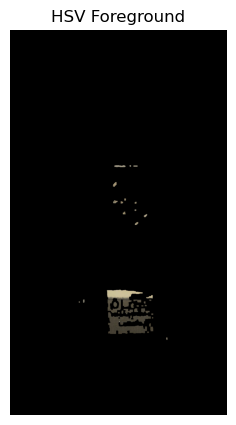

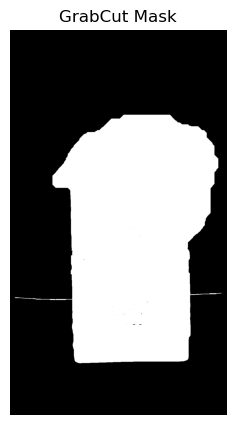

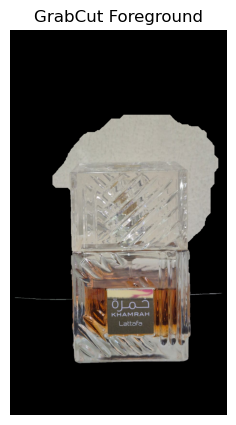

In [7]:
print("Processing:", image_path)


original, hsv_mask, hsv_fg = hsv_segment(image_path, lower_hsv, upper_hsv)

show("Original Image", original)
show("HSV Mask", hsv_mask)
show("HSV Foreground", hsv_fg)


orig2, gc_mask, gc_fg = grabcut_segment(image_path)

show("GrabCut Mask", gc_mask)
show("GrabCut Foreground", gc_fg)


In [8]:
image_path = "images/img2.jpg"   


Processing: images/img2.jpg


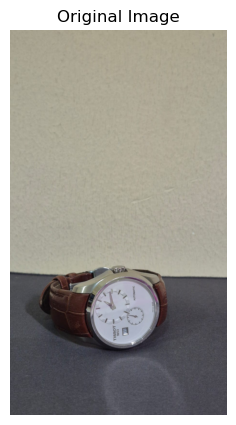

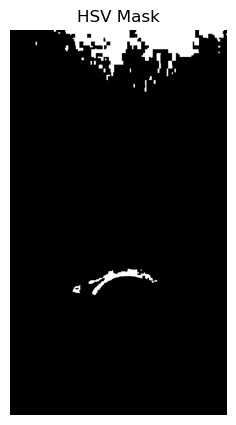

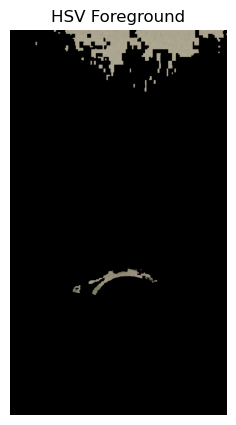

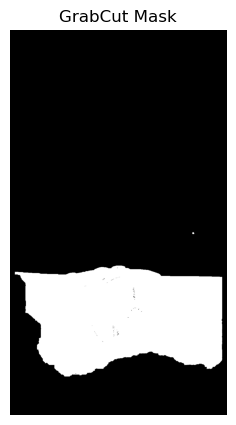

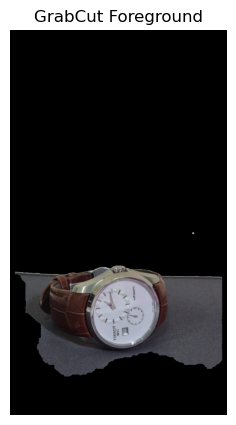

In [9]:
print("Processing:", image_path)


original, hsv_mask, hsv_fg = hsv_segment(image_path, lower_hsv, upper_hsv)

show("Original Image", original)
show("HSV Mask", hsv_mask)
show("HSV Foreground", hsv_fg)


orig2, gc_mask, gc_fg = grabcut_segment(image_path)

show("GrabCut Mask", gc_mask)
show("GrabCut Foreground", gc_fg)


In [10]:
image_path = "images/img3.jpg"   


Processing: images/img3.jpg


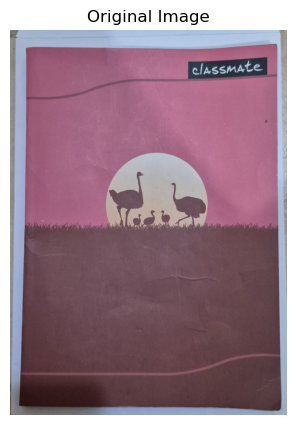

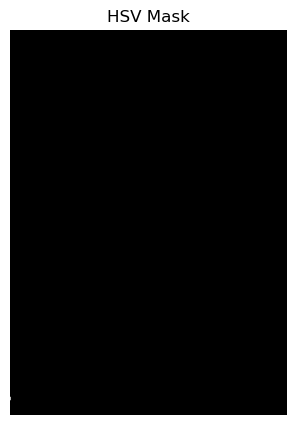

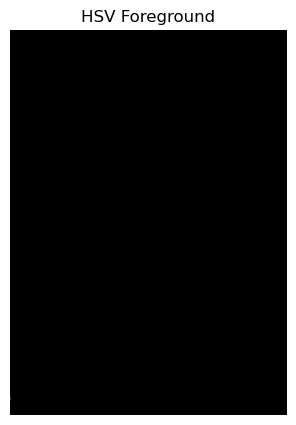

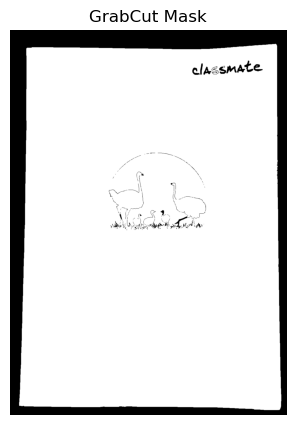

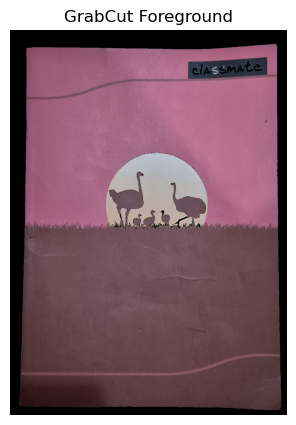

In [11]:
print("Processing:", image_path)


original, hsv_mask, hsv_fg = hsv_segment(image_path, lower_hsv, upper_hsv)

show("Original Image", original)
show("HSV Mask", hsv_mask)
show("HSV Foreground", hsv_fg)


orig2, gc_mask, gc_fg = grabcut_segment(image_path)

show("GrabCut Mask", gc_mask)
show("GrabCut Foreground", gc_fg)


In [12]:
image_path = "images/img4.jpg"  


Processing: images/img4.jpg


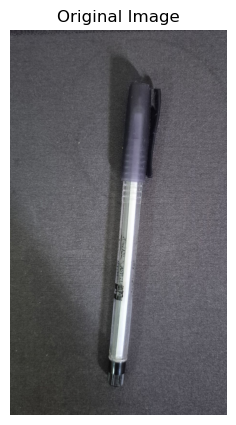

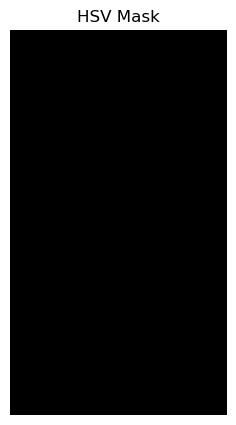

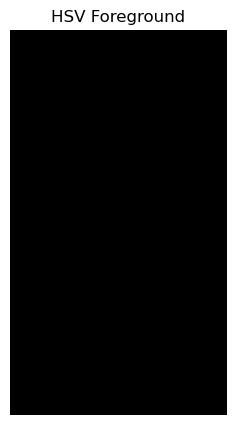

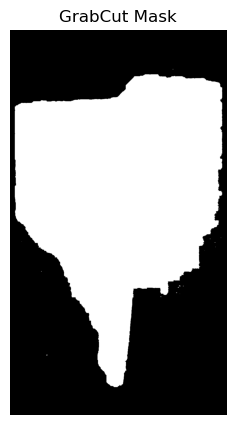

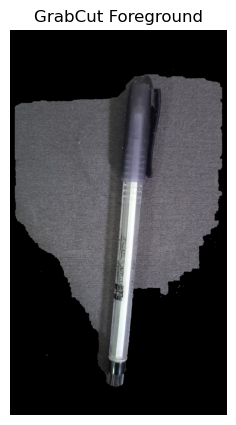

In [13]:
print("Processing:", image_path)


original, hsv_mask, hsv_fg = hsv_segment(image_path, lower_hsv, upper_hsv)

show("Original Image", original)
show("HSV Mask", hsv_mask)
show("HSV Foreground", hsv_fg)


orig2, gc_mask, gc_fg = grabcut_segment(image_path)

show("GrabCut Mask", gc_mask)
show("GrabCut Foreground", gc_fg)


In [14]:
image_path = "images/img5.jpg"   


Processing: images/img5.jpg


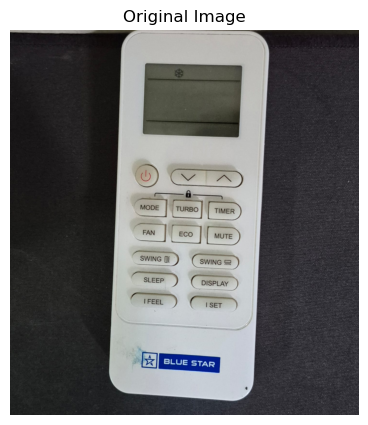

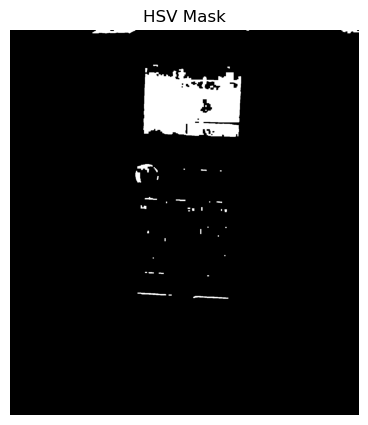

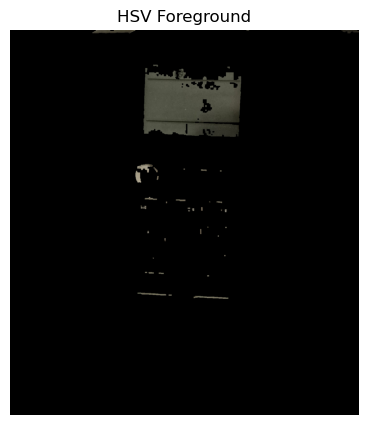

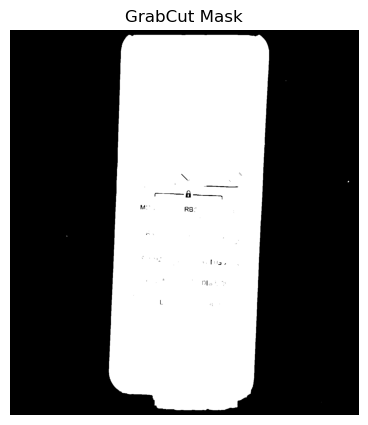

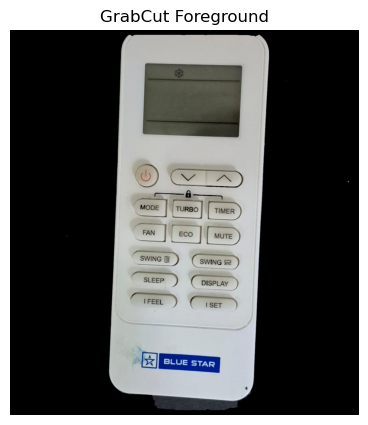

In [15]:
print("Processing:", image_path)


original, hsv_mask, hsv_fg = hsv_segment(image_path, lower_hsv, upper_hsv)

show("Original Image", original)
show("HSV Mask", hsv_mask)
show("HSV Foreground", hsv_fg)


orig2, gc_mask, gc_fg = grabcut_segment(image_path)

show("GrabCut Mask", gc_mask)
show("GrabCut Foreground", gc_fg)
